In [117]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import SimpleITK as sitk
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from NoduleDS import NoduleDataset
from torch.optim.lr_scheduler import OneCycleLR

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [118]:
BATCH_SIZE = 16
NUM_EPOCHS = 25
LEARNING_RATE = 1e-4
IMAGE_SIZE = 224
NUM_WORKERS = 4
WEIGHT_DECAY = 0.01

# Paths - using pre-split data to avoid leakage
split_base_path = "./dataset_nodule21/cxr_images/proccessed_data/split_data"

train_images_path = os.path.join(split_base_path, "train", "images")
val_images_path = os.path.join(split_base_path, "val", "images")
test_images_path = os.path.join(split_base_path, "test", "images")

train_csv_path = os.path.join(split_base_path, "train", "metadata_no_aug.csv")
val_csv_path = os.path.join(split_base_path, "val", "metadata_val.csv")
test_csv_path = os.path.join(split_base_path, "test", "metadata_test.csv")

In [119]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    #transforms.RandomHorizontalFlip(p=0.5),
    #transforms.RandomRotation(degrees=3),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [120]:
# %% Load Pre-Split Data

# Also load original data for before/after comparison 
original_csv_path = "./nodule_dataset21/cxr_images/proccessed_data/metadata.csv"

print("Loading metadata...")
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

# Try to load original data
try:
    original_df = pd.read_csv(original_csv_path)
    has_original = True
    print(f"Original dataset: {len(original_df)} samples")
except:
    has_original = False
    print("Original metadata not found, skipping before/after comparison")

print(f"Train: {len(train_df)} samples")
print(f"Val: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

# Combine all splits for total distribution
combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
print(f"Total (combined): {len(combined_df)} samples")

# %% Beautiful color palette
color_negative = '#667eea'  # Soft purple
color_positive = '#f093fb'  # Soft pink
colors = [color_negative, color_positive]

# %% Figure 1: Before vs After Upsampling (if original data exists)
if has_original:
    fig1, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig1.patch.set_facecolor('white')
    
    # Original distribution - Bar
    original_counts = original_df['label'].value_counts().sort_index()
    axes[0, 0].bar(['No Nodule', 'Nodule'], original_counts.values, 
                   color=colors, alpha=0.85, edgecolor='white', linewidth=2)
    axes[0, 0].set_ylabel('Number of Images', fontsize=13, fontweight='bold')
    axes[0, 0].set_title('Original Dataset (Before Split & Upsample)', fontsize=15, fontweight='bold', pad=15)
    axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[0, 0].set_facecolor('#ffffff')
    for i, v in enumerate(original_counts.values):
        axes[0, 0].text(i, v + 50, str(v), ha='center', va='bottom', 
                        fontsize=12, fontweight='bold', color=colors[i])
    
    # Original distribution - Pie
    wedges, texts, autotexts = axes[0, 1].pie(original_counts.values, 
                                               labels=['No Nodule', 'Nodule'], 
                                               autopct='%1.1f%%',
                                               colors=colors, 
                                               startangle=90,
                                               explode=(0.05, 0.05),
                                               shadow=True)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(11)
    for text in texts:
        text.set_fontsize(12)
        text.set_fontweight('bold')
    axes[0, 1].set_title('Original Distribution (%)', fontsize=15, fontweight='bold', pad=15)
    
    # After split & upsample - Bar
    combined_counts = combined_df['label'].value_counts().sort_index()
    axes[1, 0].bar(['No Nodule', 'Nodule'], combined_counts.values, 
                   color=colors, alpha=0.85, edgecolor='white', linewidth=2)
    axes[1, 0].set_ylabel('Number of Images', fontsize=13, fontweight='bold')
    axes[1, 0].set_title('After Split & Upsample (All Splits Combined)', fontsize=15, fontweight='bold', pad=15)
    axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1, 0].set_facecolor('#ffffff')
    for i, v in enumerate(combined_counts.values):
        axes[1, 0].text(i, v + 100, str(v), ha='center', va='bottom', 
                        fontsize=12, fontweight='bold', color=colors[i])
    
    # After split & upsample - Pie
    wedges, texts, autotexts = axes[1, 1].pie(combined_counts.values, 
                                               labels=['No Nodule', 'Nodule'], 
                                               autopct='%1.1f%%',
                                               colors=colors, 
                                               startangle=90,
                                               explode=(0.05, 0.05),
                                               shadow=True)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(11)
    for text in texts:
        text.set_fontsize(12)
        text.set_fontweight('bold')
    axes[1, 1].set_title('After Split & Upsample (%)', fontsize=15, fontweight='bold', pad=15)
    
    plt.tight_layout()
    plt.savefig('before_after_split_upsample.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print("\n✓ Before/After comparison saved to 'before_after_split_upsample.png'")

Loading metadata...
Original metadata not found, skipping before/after comparison
Train: 3657 samples
Val: 782 samples
Test: 785 samples
Total (combined): 5224 samples


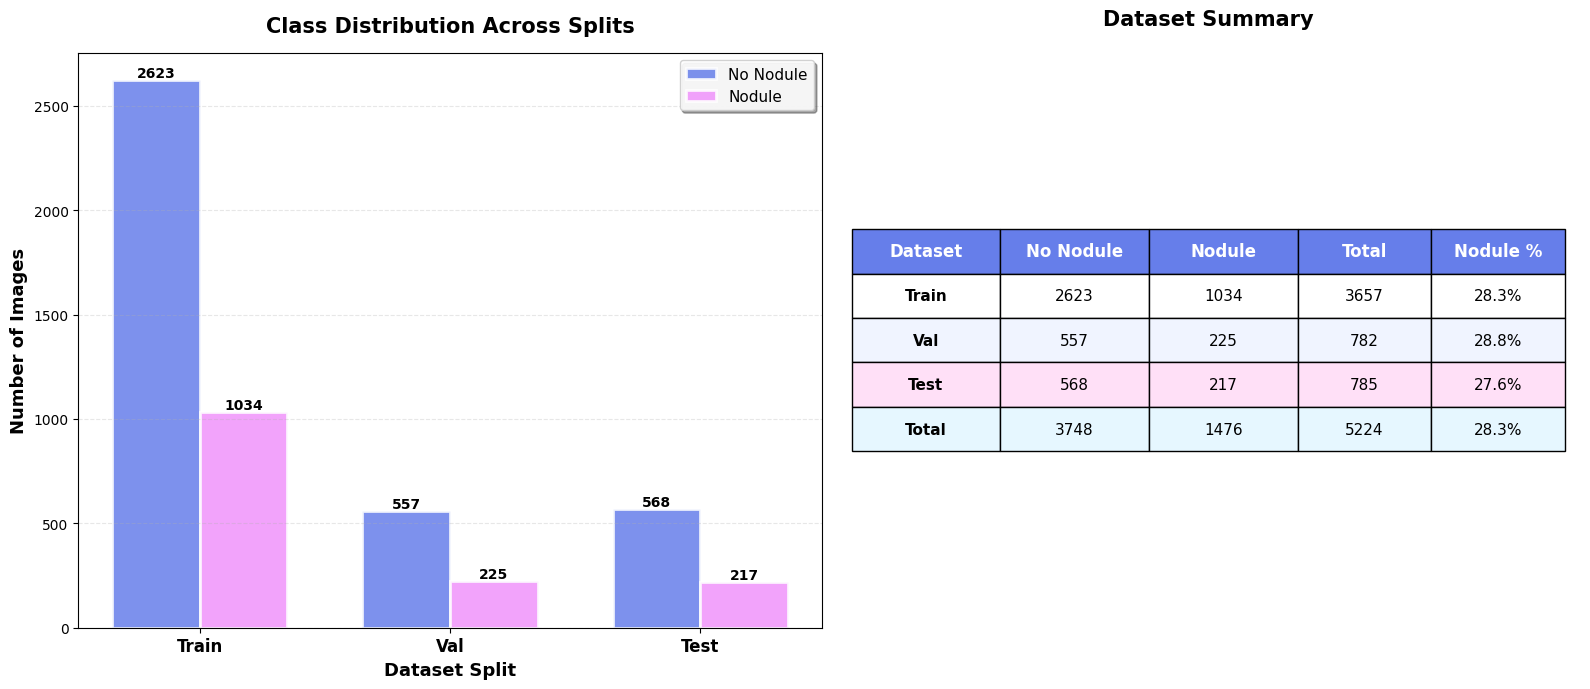

✓ Split distribution saved to 'split_distribution.png'


In [121]:
# %% Figure 2: Train/Val/Test Distribution
fig2, axes = plt.subplots(1, 2, figsize=(16, 7))
fig2.patch.set_facecolor('white')

# Grouped bar chart
splits_data = {
    'Train': train_df['label'].value_counts().sort_index(),
    'Val': val_df['label'].value_counts().sort_index(),
    'Test': test_df['label'].value_counts().sort_index()
}

x = np.arange(len(splits_data))
width = 0.35
bars1 = axes[0].bar(x - width/2, [splits_data[k][0] for k in splits_data.keys()], 
                    width, label='No Nodule', color=color_negative, alpha=0.85, 
                    edgecolor='white', linewidth=2)
bars2 = axes[0].bar(x + width/2, [splits_data[k][1] for k in splits_data.keys()], 
                    width, label='Nodule', color=color_positive, alpha=0.85, 
                    edgecolor='white', linewidth=2)

axes[0].set_xlabel('Dataset Split', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=13, fontweight='bold')
axes[0].set_title('Class Distribution Across Splits', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits_data.keys(), fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11, framealpha=0.9, shadow=True)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_facecolor('#ffffff')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Summary table
summary_data = []
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df), ('Total', combined_df)]:
    no_nodule = (split_df['label'] == 0).sum()
    nodule = (split_df['label'] == 1).sum()
    total = len(split_df)
    nodule_pct = f"{nodule/total*100:.1f}%" if total > 0 else "0%"
    summary_data.append([split_name, no_nodule, nodule, total, nodule_pct])

if has_original:
    # Add original row at the top
    orig_no_nodule = (original_df['label'] == 0).sum()
    orig_nodule = (original_df['label'] == 1).sum()
    orig_total = len(original_df)
    orig_pct = f"{orig_nodule/orig_total*100:.1f}%"
    summary_data.insert(0, ['Original', orig_no_nodule, orig_nodule, orig_total, orig_pct])

axes[1].axis('tight')
axes[1].axis('off')
table = axes[1].table(cellText=summary_data,
                      colLabels=['Dataset', 'No Nodule', 'Nodule', 'Total', 'Nodule %'],
                      cellLoc='center',
                      loc='center',
                      colWidths=[0.2, 0.2, 0.2, 0.18, 0.18])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header with gradient
for i in range(5):
    table[(0, i)].set_facecolor('#667eea')
    table[(0, i)].set_text_props(weight='bold', color='white', size=12)

# Alternate row colors
row_colors = ['#ffffff', '#f0f4ff', '#ffe0f7', '#e6f7ff', '#e8f5e9', '#fff3e0']
for i in range(1, len(summary_data) + 1):
    for j in range(5):
        table[(i, j)].set_facecolor(row_colors[(i-1) % len(row_colors)])
        table[(i, j)].set_text_props(weight='normal' if j > 0 else 'bold')

axes[1].set_title('Dataset Summary', fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Split distribution saved to 'split_distribution.png'")

In [122]:
# %% Print detailed statistics
print("\n" + "="*70)
print("📊 DETAILED STATISTICS")
print("="*70)

if has_original:
    print("\nORIGINAL DATASET (Before Split):")
    print(f"   Total images: {len(original_df)}")
    print(f"   No Nodule (0): {original_counts[0]:,} ({original_counts[0]/len(original_df)*100:.1f}%)")
    print(f"   Nodule (1): {original_counts[1]:,} ({original_counts[1]/len(original_df)*100:.1f}%)")
    print(f"   Imbalance ratio: 1:{original_counts[0]/original_counts[1]:.2f}")

print("\nAFTER SPLIT & UPSAMPLE:")
print(f"   Total images (combined): {len(combined_df)}")
combined_counts = combined_df['label'].value_counts().sort_index()
print(f"   No Nodule (0): {combined_counts[0]:,} ({combined_counts[0]/len(combined_df)*100:.1f}%)")
print(f"   Nodule (1): {combined_counts[1]:,} ({combined_counts[1]/len(combined_df)*100:.1f}%)")
print(f"   Imbalance ratio: 1:{combined_counts[0]/combined_counts[1]:.2f}")

print("\nINDIVIDUAL SPLITS:")
train_counts = train_df['label'].value_counts().sort_index()
print(f"\n   Training Set ({len(train_df)} images):")
print(f"      No Nodule: {train_counts[0]:,} ({train_counts[0]/len(train_df)*100:.1f}%)")
print(f"      Nodule: {train_counts[1]:,} ({train_counts[1]/len(train_df)*100:.1f}%)")

val_counts = val_df['label'].value_counts().sort_index()
print(f"\n   Validation Set ({len(val_df)} images):")
print(f"      No Nodule: {val_counts[0]:,} ({val_counts[0]/len(val_df)*100:.1f}%)")
print(f"      Nodule: {val_counts[1]:,} ({val_counts[1]/len(val_df)*100:.1f}%)")

test_counts = test_df['label'].value_counts().sort_index()
print(f"\n   Test Set ({len(test_df)} images):")
print(f"      No Nodule: {test_counts[0]:,} ({test_counts[0]/len(test_df)*100:.1f}%)")
print(f"      Nodule: {test_counts[1]:,} ({test_counts[1]/len(test_df)*100:.1f}%)")

print("\n" + "="*70)
print("✨ All visualizations saved successfully!")
print("="*70)


📊 DETAILED STATISTICS

AFTER SPLIT & UPSAMPLE:
   Total images (combined): 5224
   No Nodule (0): 3,748 (71.7%)
   Nodule (1): 1,476 (28.3%)
   Imbalance ratio: 1:2.54

INDIVIDUAL SPLITS:

   Training Set (3657 images):
      No Nodule: 2,623 (71.7%)
      Nodule: 1,034 (28.3%)

   Validation Set (782 images):
      No Nodule: 557 (71.2%)
      Nodule: 225 (28.8%)

   Test Set (785 images):
      No Nodule: 568 (72.4%)
      Nodule: 217 (27.6%)

✨ All visualizations saved successfully!


In [123]:
# Create datasets - each pointing to its own split directory
train_dataset = NoduleDataset(train_df, train_images_path, transform=train_transform, return_bbox=True)
val_dataset = NoduleDataset(val_df, val_images_path, transform=val_transform, return_bbox=True)
test_dataset = NoduleDataset(test_df, test_images_path, transform=val_transform, return_bbox=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=NUM_WORKERS, pin_memory=True)

In [124]:
def ciou_loss(pred_bbox, target_bbox):
    """
    Complete-IoU Loss (BEST for medical nodule detection)
    Considers IoU + center distance + aspect ratio
    """
    # Convert [x, y, w, h] to [x1, y1, x2, y2]
    pred_x1, pred_y1 = pred_bbox[:, 0], pred_bbox[:, 1]
    pred_x2 = pred_bbox[:, 0] + pred_bbox[:, 2]
    pred_y2 = pred_bbox[:, 1] + pred_bbox[:, 3]
    
    target_x1, target_y1 = target_bbox[:, 0], target_bbox[:, 1]
    target_x2 = target_bbox[:, 0] + target_bbox[:, 2]
    target_y2 = target_bbox[:, 1] + target_bbox[:, 3]
    
    # Intersection
    inter_x1 = torch.max(pred_x1, target_x1)
    inter_y1 = torch.max(pred_y1, target_y1)
    inter_x2 = torch.min(pred_x2, target_x2)
    inter_y2 = torch.min(pred_y2, target_y2)
    
    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
    inter_area = inter_w * inter_h
    
    # Union
    pred_area = pred_bbox[:, 2] * pred_bbox[:, 3]
    target_area = target_bbox[:, 2] * target_bbox[:, 3]
    union_area = pred_area + target_area - inter_area
    
    # IoU
    iou = inter_area / (union_area + 1e-7)
    
    # Center point distance
    pred_center_x = pred_bbox[:, 0] + pred_bbox[:, 2] / 2
    pred_center_y = pred_bbox[:, 1] + pred_bbox[:, 3] / 2
    target_center_x = target_bbox[:, 0] + target_bbox[:, 2] / 2
    target_center_y = target_bbox[:, 1] + target_bbox[:, 3] / 2
    
    center_distance = (pred_center_x - target_center_x) ** 2 + \
                     (pred_center_y - target_center_y) ** 2
    
    # Diagonal length of enclosing box
    enclose_x1 = torch.min(pred_x1, target_x1)
    enclose_y1 = torch.min(pred_y1, target_y1)
    enclose_x2 = torch.max(pred_x2, target_x2)
    enclose_y2 = torch.max(pred_y2, target_y2)
    
    enclose_diagonal = (enclose_x2 - enclose_x1) ** 2 + \
                       (enclose_y2 - enclose_y1) ** 2
    
    # Aspect ratio consistency
    pred_w, pred_h = pred_bbox[:, 2], pred_bbox[:, 3]
    target_w, target_h = target_bbox[:, 2], target_bbox[:, 3]
    
    v = (4 / (torch.pi ** 2)) * torch.pow(
        torch.atan(target_w / (target_h + 1e-7)) - 
        torch.atan(pred_w / (pred_h + 1e-7)), 2)
    
    with torch.no_grad():
        alpha = v / (1 - iou + v + 1e-7)
    
    # CIoU = IoU - (center_distance / enclose_diagonal) - alpha * v
    ciou = iou - (center_distance / (enclose_diagonal + 1e-7)) - alpha * v
    
    return (1 - ciou).mean()

In [125]:
# %% Calculate class weights for imbalanced dataset
print("\nCalculating class weights for imbalanced dataset...")

# Count class distribution in training set
train_labels = train_df['label'].values
class_counts = np.bincount(train_labels)
print(f"Training set distribution:")
print(f"  Class 0 (No Nodule): {class_counts[0]} samples")
print(f"  Class 1 (Nodule): {class_counts[1]} samples")

# Calculate weights: inverse of class frequency
total_samples = len(train_labels)
class_weights = total_samples / (len(class_counts) * class_counts)
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"\nCalculated class weights:")
print(f"  Class 0 weight: {class_weights[0]:.4f}")
print(f"  Class 1 weight: {class_weights[1]:.4f}")

import torch.nn.functional as F

ATTENTION_LOSS_WEIGHT = 0.5


print("\n✓ Using weighted CrossEntropyLoss to handle class imbalance")
print("✓ Using GIoU Loss for bounding box regression")


Calculating class weights for imbalanced dataset...
Training set distribution:
  Class 0 (No Nodule): 2623 samples
  Class 1 (Nodule): 1034 samples

Calculated class weights:
  Class 0 weight: 0.6971
  Class 1 weight: 1.7684

✓ Using weighted CrossEntropyLoss to handle class imbalance
✓ Using GIoU Loss for bounding box regression


In [126]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import numpy as np
from tqdm import tqdm

class FPN(nn.Module):
    """Feature Pyramid Network - Standard for small object detection"""
    def __init__(self, in_channels_list=[256, 512, 1024, 2048], out_channels=256):
        super().__init__()
        
        # Lateral 1x1 convs
        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(in_ch, out_channels, 1) for in_ch in in_channels_list
        ])
        
        # 3x3 convs to smooth upsampled features
        self.output_convs = nn.ModuleList([
            nn.Conv2d(out_channels, out_channels, 3, padding=1) for _ in in_channels_list
        ])
    
    def forward(self, features):
        """features: [c2, c3, c4, c5] from ResNet stages"""
        # Lateral connections
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]
        
        # Top-down pathway with upsampling
        for i in range(len(laterals) - 1, 0, -1):
            laterals[i-1] = laterals[i-1] + F.interpolate(
                laterals[i], size=laterals[i-1].shape[-2:], mode='nearest'
            )
        
        # Apply 3x3 convs
        outputs = [conv(lat) for conv, lat in zip(self.output_convs, laterals)]
        return outputs

class ResNetFPNAttention(nn.Module):
    """ResNet-50 + FPN with Attention Guidance (NO bbox prediction)"""
    def __init__(self, num_classes=2, pretrained=True, fpn_channels=256):
        super().__init__()
        
        backbone = timm.create_model('resnet50', pretrained=pretrained, num_classes=0)
        
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.act1, backbone.maxpool)
        self.stage1 = backbone.layer1  # C2: 256ch, 56×56
        self.stage2 = backbone.layer2  # C3: 512ch, 28×28
        self.stage3 = backbone.layer3  # C4: 1024ch, 14×14
        self.stage4 = backbone.layer4  # C5: 2048ch, 7×7
        
        # Classification head (from C5)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(2048, num_classes)
        
        # FPN
        self.fpn = FPN([256, 512, 1024, 2048], fpn_channels)
        
        # Store feature maps for attention computation
        self.fpn_features = None
        
    def forward(self, x):
        # Backbone
        x = self.stem(x)
        c2 = self.stage1(x)
        c3 = self.stage2(c2)
        c4 = self.stage3(c3)
        c5 = self.stage4(c4)
        
        # Classification from C5
        pooled = self.global_pool(c5)
        class_logits = self.classifier(pooled.flatten(1))
        
        # FPN (store for attention)
        self.fpn_features = self.fpn([c2, c3, c4, c5])  # [P2, P3, P4, P5]
        
        return class_logits
    
    def get_attention_map(self, class_idx=1, size=(224, 224)):
        """
        Generate attention map using FPN P2 features (highest resolution)
        Similar to CAM but using FPN features
        """
        if self.fpn_features is None:
            return None
        
        # Use P2 (highest resolution FPN level)
        p2_features = self.fpn_features[0]  # Shape: (batch, 256, 56, 56)
        
        # Get classifier weights for target class
        weights = self.classifier.weight[class_idx]  # Shape: (2048,)
        
        # Since P2 has 256 channels but classifier uses 2048 from C5,
        # we use a simple spatial pooling approach instead
        # Alternative: compute attention from P2 features directly
        
        # Simple approach: use mean activation across channels
        attention = p2_features.mean(dim=1)  # (batch, 56, 56)
        
        # Apply ReLU and normalize
        attention = F.relu(attention)
        attention = attention - attention.min()
        attention = attention / (attention.max() + 1e-8)
        
        # Upsample to target size
        attention = F.interpolate(
            attention.unsqueeze(1),
            size=size,
            mode='bilinear',
            align_corners=False
        ).squeeze(1)
        
        return attention


def create_attention_target(bboxes, feature_map_size=(56, 56), image_size=(224, 224), 
                           margin=40, temperature=2.0):
    """
    Create target attention maps from bboxes with generous margins
    
    Args:
        bboxes: (batch, 4) ground truth boxes as [x, y, w, h] in normalized coords [0,1]
        feature_map_size: Size of attention map to create
        image_size: Original image size
        margin: Pixels to expand around bbox (in feature map coords)
        temperature: Softness of the Gaussian target
    
    Returns:
        target_masks: (batch, H, W) soft target attention maps
    """
    batch_size = bboxes.shape[0]
    att_h, att_w = feature_map_size
    
    target_mask = torch.zeros(batch_size, att_h, att_w, device=bboxes.device)
    
    for i in range(batch_size):
        x, y, w, h = bboxes[i]
        
        # Skip if bbox is invalid (e.g., negative samples)
        if x < 0 or y < 0 or w <= 0 or h <= 0:
            continue
        
        # Scale bbox coordinates to feature map size
        scale_x = att_w / image_size[1]
        scale_y = att_h / image_size[0]
        
        x_scaled = int(x * image_size[1] * scale_x)
        y_scaled = int(y * image_size[0] * scale_y)
        w_scaled = int(w * image_size[1] * scale_x)
        h_scaled = int(h * image_size[0] * scale_y)
        
        # Expand with margin
        x1 = max(0, x_scaled - margin)
        y1 = max(0, y_scaled - margin)
        x2 = min(att_w, x_scaled + w_scaled + margin)
        y2 = min(att_h, y_scaled + h_scaled + margin)
        
        # Create soft Gaussian target (higher weight at center)
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2
        
        y_coords, x_coords = torch.meshgrid(
            torch.arange(att_h, device=bboxes.device),
            torch.arange(att_w, device=bboxes.device),
            indexing='ij'
        )
        
        # Gaussian-like weight (higher at center, fading at edges)
        max_dist = np.sqrt((x2 - x1)**2 + (y2 - y1)**2) / 2
        dist = torch.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)
        
        # Only apply within expanded bbox region
        mask = (x_coords >= x1) & (x_coords < x2) & (y_coords >= y1) & (y_coords < y2)
        weights = torch.exp(-dist / (max_dist / temperature))
        target_mask[i] = weights * mask.float()
    
    # Normalize to sum to 1 (make it a probability distribution)
    target_mask = target_mask / (target_mask.sum(dim=(1, 2), keepdim=True) + 1e-8)
    
    return target_mask


def attention_guidance_loss(attention_map, bboxes, image_size=(224, 224), 
                            margin=40, temperature=2.0):
    """
    Guides the attention map to cover the bbox region with generous margin
    Uses KL divergence to match target distribution
    """
    # Create target attention distribution
    target_mask = create_attention_target(
        bboxes, 
        feature_map_size=attention_map.shape[1:3],
        image_size=image_size,
        margin=margin,
        temperature=temperature
    )
    
    # Normalize attention map to probability distribution
    attention_norm = attention_map / (attention_map.sum(dim=(1, 2), keepdim=True) + 1e-8)
    
    # KL divergence loss
    loss = F.kl_div(
        (attention_norm + 1e-8).log(),
        target_mask,
        reduction='batchmean'
    )
    
    return loss



Initializing ResNet-50 with FPN (AGGRESSIVE bbox learning)...
Loading pretrained ResNet-50 weights...
✓ Loaded pretrained backbone weights

Trainable: 26,848,006 / 26,857,542 (100.0%)
✓ Using PURE L1 Loss for bbox regression

✓ AGGRESSIVE FPN model ready!
✓ Using P2 (56×56) features for bbox regression
✓ BBox loss weight: 20.0
✓ Learning rate: 5.00e-05 → 2.50e-04
✓ Simplified bbox head (direct linear mapping)
✓ Unfroze stage1-4 (only stem frozen)


In [127]:
# %% Initialize FPN Model
print("\nInitializing ResNet-50 with FPN for small nodule detection...")
model = ResNetFPNAttention(num_classes=2, pretrained=False, fpn_channels=256)

# Load pretrained weights
print("Loading pretrained ResNet-50 weights...")
checkpoint = torch.load('./resnet50_binary.pth')
pretrained_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint

model_dict = model.state_dict()
pretrained_dict_filtered = {}

for k, v in pretrained_dict.items():
    if k.startswith('conv1'):
        pretrained_dict_filtered['stem.0.' + k] = v
    elif k.startswith('bn1'):
        pretrained_dict_filtered['stem.1.' + k] = v
    elif k.startswith('layer1'):
        pretrained_dict_filtered['stage1.' + k[7:]] = v
    elif k.startswith('layer2'):
        pretrained_dict_filtered['stage2.' + k[7:]] = v
    elif k.startswith('layer3'):
        pretrained_dict_filtered['stage3.' + k[7:]] = v
    elif k.startswith('layer4'):
        pretrained_dict_filtered['stage4.' + k[7:]] = v
    elif k.startswith('fc'):
        pretrained_dict_filtered['classifier.' + k[3:]] = v

model_dict.update(pretrained_dict_filtered)
model.load_state_dict(model_dict, strict=False)
print("✓ Loaded pretrained backbone weights")

model = model.to(device)

# Freeze early stages, train deep + FPN + bbox
for name, param in model.named_parameters():
    if 'stem' in name or 'stage1' in name:
        param.requires_grad = False  # Freeze early features
    else:
        param.requires_grad = True  # Train stage2-4, FPN, heads

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\nTrainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

ATTENTION_LOSS_WEIGHT = 0.5

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                       lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = OneCycleLR(
    optimizer, 
    max_lr=LEARNING_RATE,
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,  # Warmup for 30% of training
    anneal_strategy='cos'
)

print("\n✓ FPN model ready for small nodule detection!")
print(f"✓ Using P2 (56×56) features for bbox regression")
print(f"✓ BBox loss weight: {BBOX_LOSS_WEIGHT}")


Initializing ResNet-50 with FPN for small nodule detection...
Loading pretrained ResNet-50 weights...
✓ Loaded pretrained backbone weights

Trainable: 26,632,198 / 26,857,542 (99.2%)
✓ Using PURE L1 Loss for bbox regression

✓ FPN model ready for small nodule detection!
✓ Using P2 (56×56) features for bbox regression
✓ BBox loss weight: 20.0


In [ ]:
# %% Training Functions (Updated for OneCycleLR)
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def train_epoch(model, loader, criterion_cls, optimizer, scheduler, device, 
                lambda_attention=0.5, image_size=(224, 224)):
    """Training loop with attention guidance"""
    model.train()
    running_loss = 0.0
    running_cls_loss = 0.0
    running_att_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(loader, desc='Training')
    for images, labels, bboxes in pbar:
        images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        class_logits = model(images)
        
        # Classification loss
        cls_loss = criterion_cls(class_logits, labels)
        
        # Attention guidance loss (only for positive samples)
        positive_mask = (labels == 1)
        if positive_mask.sum() > 0:
            # Get attention maps
            attention_maps = model.get_attention_map(class_idx=1, size=(56, 56))
            
            if attention_maps is not None:
                att_loss = attention_guidance_loss(
                    attention_maps[positive_mask],
                    bboxes[positive_mask],
                    image_size=image_size,
                    margin=40,  # Generous margin for small nodules
                    temperature=2.0
                )
            else:
                att_loss = torch.tensor(0.0, device=device)
        else:
            att_loss = torch.tensor(0.0, device=device)
        
        # Combined loss
        loss = cls_loss + lambda_attention * att_loss
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        running_loss += loss.item()
        running_cls_loss += cls_loss.item()
        running_att_loss += att_loss.item() if isinstance(att_loss, torch.Tensor) else 0
        
        probs = torch.softmax(class_logits, dim=1)
        _, predicted = class_logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().detach().numpy())
        
        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix({
            'loss': running_loss/len(pbar),
            'cls': running_cls_loss/len(pbar),
            'att': running_att_loss/len(pbar),
            'acc': 100.*correct/total,
            'lr': f'{current_lr:.2e}'
        })
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs


def validate(model, loader, criterion_cls, device, lambda_attention=0.5, image_size=(224, 224)):
    """Validation loop"""
    model.eval()
    running_loss = 0.0
    running_cls_loss = 0.0
    running_att_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels, bboxes in tqdm(loader, desc='Validation'):
            images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)
            
            class_logits = model(images)
            cls_loss = criterion_cls(class_logits, labels)
            
            # Calculate attention loss for monitoring
            positive_mask = (labels == 1)
            if positive_mask.sum() > 0:
                attention_maps = model.get_attention_map(class_idx=1, size=(56, 56))
                if attention_maps is not None:
                    att_loss = attention_guidance_loss(
                        attention_maps[positive_mask],
                        bboxes[positive_mask],
                        image_size=image_size,
                        margin=40,
                        temperature=2.0
                    )
                else:
                    att_loss = torch.tensor(0.0, device=device)
            else:
                att_loss = torch.tensor(0.0, device=device)
            
            loss = cls_loss + lambda_attention * att_loss
            
            running_loss += loss.item()
            running_cls_loss += cls_loss.item()
            running_att_loss += att_loss.item() if isinstance(att_loss, torch.Tensor) else 0
            
            probs = torch.softmax(class_logits, dim=1)
            _, predicted = class_logits.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
    
    binary_precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    binary_auc = roc_auc_score(all_labels, all_probs)
    
    avg_att_loss = running_att_loss / len(loader)
    
    return (epoch_loss, epoch_acc, all_preds, all_labels, all_probs, 
            binary_precision, binary_recall, binary_f1, binary_auc, avg_att_loss)


def calculate_attention_bbox_overlap(attention_map, bbox, threshold=0.5):
    """
    Calculate if attention overlaps with bbox region
    
    Args:
        attention_map: (H, W) attention map, already normalized to [0,1]
        bbox: (4,) ground truth box as [x, y, w, h] in normalized coords
        threshold: Attention values above this are considered "active"
    
    Returns:
        overlap_ratio: Ratio of bbox area covered by high-attention regions
        pointing_game: 1 if max attention is inside bbox, 0 otherwise
    """
    H, W = attention_map.shape
    x, y, w, h = bbox
    
    # Convert normalized bbox to pixel coordinates
    x1 = int(x * W)
    y1 = int(y * H)
    x2 = int((x + w) * W)
    y2 = int((y + h) * H)
    
    # Clamp to valid range
    x1, x2 = max(0, x1), min(W, x2)
    y1, y2 = max(0, y1), min(H, y2)
    
    # Extract bbox region from attention map
    bbox_attention = attention_map[y1:y2, x1:x2]
    
    if bbox_attention.numel() == 0:
        return 0.0, 0
    
    # Overlap ratio: what fraction of bbox has high attention
    high_attention = (bbox_attention > threshold).float()
    overlap_ratio = high_attention.mean().item()
    
    # Pointing game: is max attention inside bbox?
    max_y, max_x = torch.where(attention_map == attention_map.max())
    if len(max_y) > 0:
        max_y, max_x = max_y[0].item(), max_x[0].item()
        pointing_game = 1 if (y1 <= max_y < y2 and x1 <= max_x < x2) else 0
    else:
        pointing_game = 0
    
    return overlap_ratio, pointing_game


def evaluate_attention_quality(model, loader, device, image_size=(224, 224)):
    """
    Evaluate how well attention maps cover the nodule regions
    """
    model.eval()
    
    all_overlaps = []
    all_pointing_games = []
    
    print("\nEvaluating attention quality...")
    with torch.no_grad():
        for images, labels, bboxes in tqdm(loader, desc='Evaluating Attention'):
            images = images.to(device)
            
            # Only evaluate on positive samples
            positive_mask = (labels == 1)
            if positive_mask.sum() == 0:
                continue
            
            # Get attention maps
            _ = model(images)  # Forward pass to populate features
            attention_maps = model.get_attention_map(class_idx=1, size=image_size)
            
            if attention_maps is None:
                continue
            
            # Evaluate each positive sample
            for i, pos_idx in enumerate(torch.where(positive_mask)[0]):
                att_map = attention_maps[pos_idx].cpu()
                bbox = bboxes[pos_idx].cpu().numpy()
                
                overlap, pg = calculate_attention_bbox_overlap(att_map, bbox, threshold=0.5)
                all_overlaps.append(overlap)
                all_pointing_games.append(pg)
    
    if len(all_overlaps) == 0:
        return 0.0, 0.0
    
    mean_overlap = np.mean(all_overlaps)
    pointing_game_acc = np.mean(all_pointing_games) * 100
    
    return mean_overlap, pointing_game_acc

In [129]:
# %% Training Loop with bbox monitoring
print("\nStarting training with bbox debugging...")
history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [], 'train_precision': [],
    'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_precision': [],
    'val_bbox_std': []  # ← Track bbox variance
}

best_val_acc = 0.0
best_model_path = 'best_resnet_fpn_bbox_aggressive.pth'

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc, train_preds, train_labels, train_probs = train_epoch(
        model, train_loader, criterion_cls, criterion_bbox, optimizer, scheduler, device, BBOX_LOSS_WEIGHT)
    
    train_auc = roc_auc_score(train_labels, train_probs)
    train_precision = precision_score(train_labels, train_preds, average='binary', zero_division=0)
    
    # Validate
    val_loss, val_acc, val_preds, val_labels, val_probs, val_precision, val_recall, val_f1, val_auc = validate(
        model, val_loader, criterion_cls, criterion_bbox, device, BBOX_LOSS_WEIGHT)
    
    # ===== CHECK BBOX VARIANCE =====
    model.eval()
    bbox_samples = []
    with torch.no_grad():
        for i, (images, labels, bboxes) in enumerate(val_loader):
            if i >= 3:  # Just check first 3 batches
                break
            images = images.to(device)
            _, bbox_pred = model(images)
            bbox_samples.append(bbox_pred.cpu().numpy())
    
    bbox_samples = np.vstack(bbox_samples)
    bbox_std = bbox_samples.std()
    
    print(f"\nBBox Prediction Variance: {bbox_std:.5f}")
    if bbox_std < 0.01:
        print("⚠️  WARNING: BBox predictions not varying! Model might be stuck.")
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['train_precision'].append(train_precision)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_precision'].append(val_precision)
    history['val_bbox_std'].append(bbox_std)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Train AUC: {train_auc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val AUC: {val_auc:.4f}")
    print(f"Current LR: {current_lr:.2e}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_auc': val_auc,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1': val_f1,
            'val_bbox_std': bbox_std,
        }, best_model_path)
        print(f"✓ Saved best model (Val Acc: {val_acc:.2f}%, Val AUC: {val_auc:.4f})")

print("\nTraining completed!")

# ===== FINAL BBOX CHECK =====
print("\n" + "="*60)
print("FINAL BBOX PREDICTION CHECK")
print("="*60)
model.eval()
all_preds = []
all_gts = []

with torch.no_grad():
    for images, labels, bboxes in test_loader:
        images = images.to(device)
        _, bbox_pred = model(images)
        
        positive_mask = (labels == 1)
        if positive_mask.sum() > 0:
            all_preds.append(bbox_pred[positive_mask].cpu().numpy())
            all_gts.append(bboxes[positive_mask].numpy())

all_preds = np.vstack(all_preds)
all_gts = np.vstack(all_gts)

print(f"\nPredicted BBox (nodules only, n={len(all_preds)}):")
print(f"  X: mean={all_preds[:, 0].mean():.3f}, std={all_preds[:, 0].std():.4f}")
print(f"  Y: mean={all_preds[:, 1].mean():.3f}, std={all_preds[:, 1].std():.4f}")
print(f"  W: mean={all_preds[:, 2].mean():.3f}, std={all_preds[:, 2].std():.4f}")
print(f"  H: mean={all_preds[:, 3].mean():.3f}, std={all_preds[:, 3].std():.4f}")

print(f"\nGround Truth BBox:")
print(f"  X: mean={all_gts[:, 0].mean():.3f}, std={all_gts[:, 0].std():.4f}")
print(f"  Y: mean={all_gts[:, 1].mean():.3f}, std={all_gts[:, 1].std():.4f}")
print(f"  W: mean={all_gts[:, 2].mean():.3f}, std={all_gts[:, 2].std():.4f}")
print(f"  H: mean={all_gts[:, 3].mean():.3f}, std={all_gts[:, 3].std():.4f}")

print(f"\nModel stuck? {all_preds.std() < 0.01}")


Starting training with bbox debugging...

Epoch 1/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:19<00:00,  2.54it/s]



BBox Prediction Variance: 0.22222
Train Loss: 4.4865, Train Acc: 51.05%, Train AUC: 0.6283
Val Loss: 2.3797, Val Acc: 56.27%, Val AUC: 0.7279
Current LR: 8.15e-06
✓ Saved best model (Val Acc: 56.27%, Val AUC: 0.7279)

Epoch 2/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:16<00:00,  3.02it/s]



BBox Prediction Variance: 0.17559
Train Loss: 3.4272, Train Acc: 58.71%, Train AUC: 0.7230
Val Loss: 1.4823, Val Acc: 68.80%, Val AUC: 0.8463
Current LR: 1.99e-05
✓ Saved best model (Val Acc: 68.80%, Val AUC: 0.8463)

Epoch 3/25
--------------------------------------------------


...


BBox Prediction Variance: 0.19396
Train Loss: 1.2584, Train Acc: 97.79%, Train AUC: 0.9973
Val Loss: 0.9231, Val Acc: 89.51%, Val AUC: 0.9558
Current LR: 3.17e-06

Epoch 24/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:15<00:00,  3.22it/s]



BBox Prediction Variance: 0.20220
Train Loss: 1.2200, Train Acc: 97.73%, Train AUC: 0.9979
Val Loss: 0.9025, Val Acc: 89.77%, Val AUC: 0.9562
Current LR: 7.97e-07

Epoch 25/25
--------------------------------------------------


Validation: 100%|██████████| 49/49 [00:15<00:00,  3.09it/s]



BBox Prediction Variance: 0.20030
Train Loss: 1.1983, Train Acc: 98.44%, Train AUC: 0.9987
Val Loss: 0.9007, Val Acc: 90.15%, Val AUC: 0.9574
Current LR: 4.15e-10

Training completed!

FINAL BBOX PREDICTION CHECK

Predicted BBox (nodules only, n=217):
  X: mean=0.414, std=0.1257
  Y: mean=0.463, std=0.1021
  W: mean=0.049, std=0.0085
  H: mean=0.051, std=0.0083

Ground Truth BBox:
  X: mean=0.414, std=0.2523
  Y: mean=0.498, std=0.1543
  W: mean=0.056, std=0.0209
  H: mean=0.059, std=0.0223

Model stuck? False


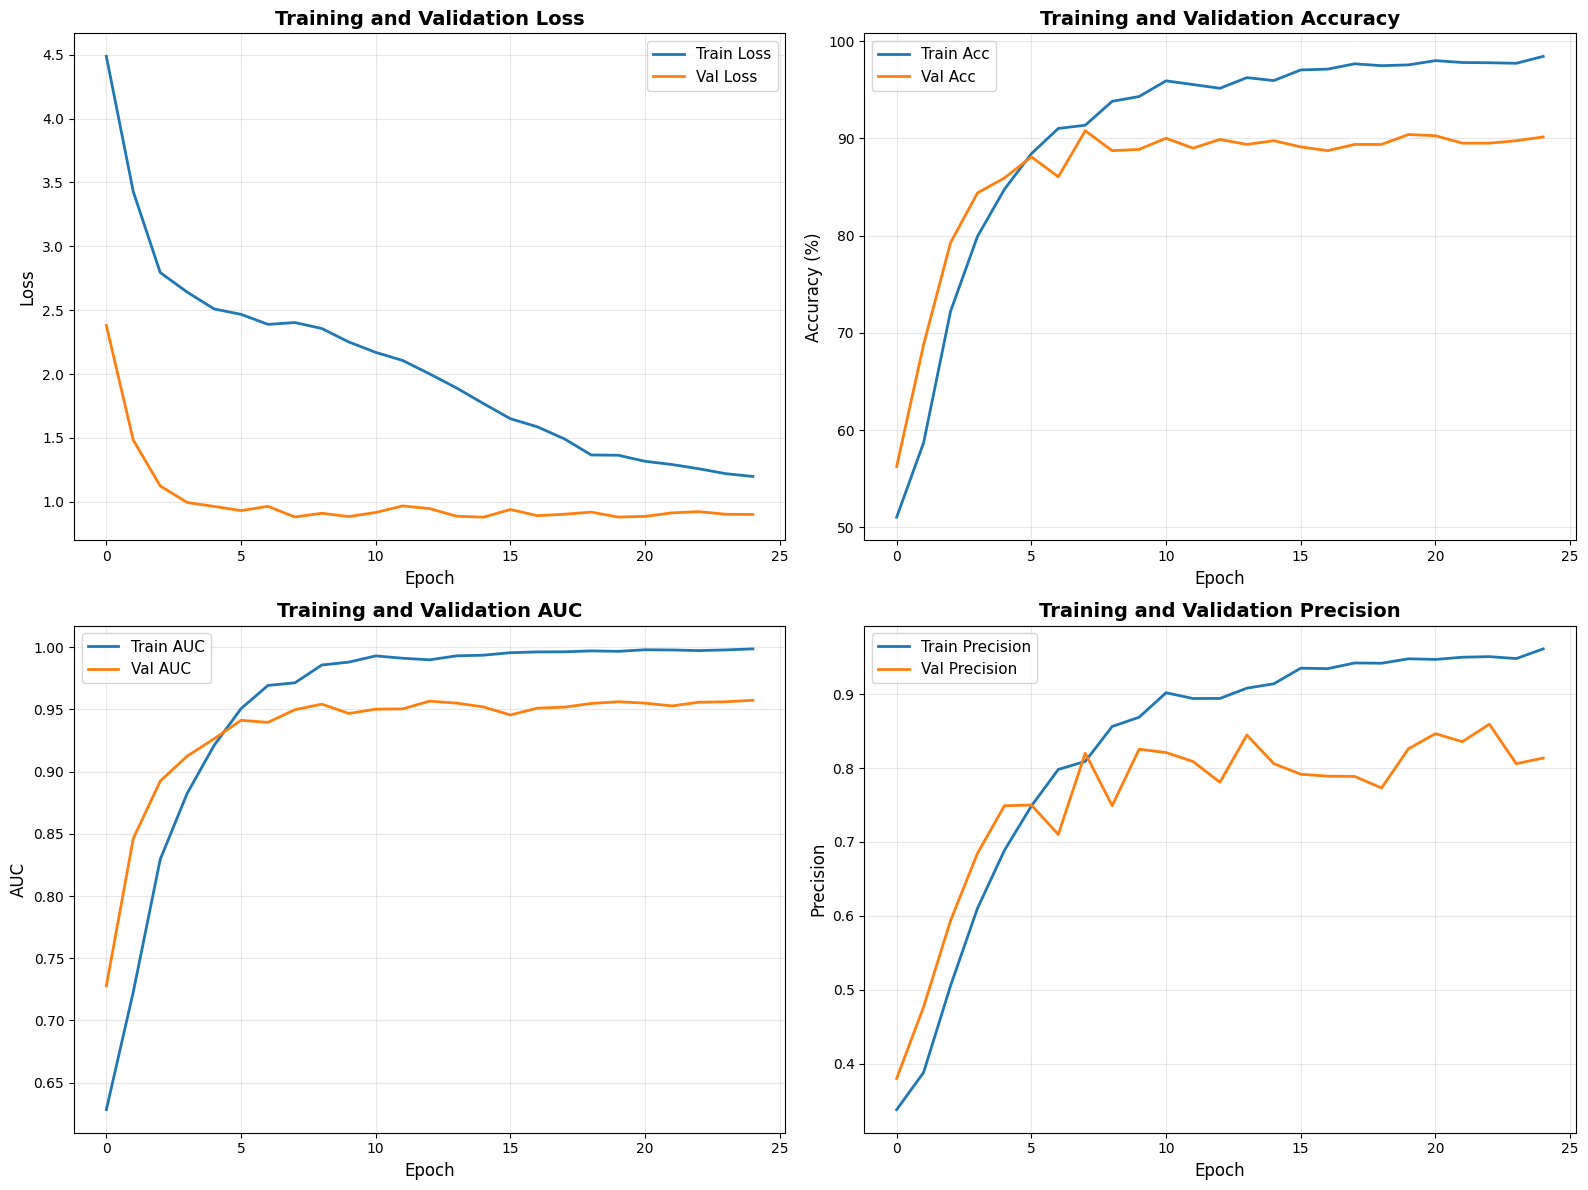

In [130]:
# %% Plot Training History
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# AUC plot
ax3.plot(history['train_auc'], label='Train AUC', linewidth=2)
ax3.plot(history['val_auc'], label='Val AUC', linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('AUC', fontsize=12)
ax3.set_title('Training and Validation AUC', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Precision plot
ax4.plot(history['train_precision'], label='Train Precision', linewidth=2)
ax4.plot(history['val_precision'], label='Val Precision', linewidth=2)
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Precision', fontsize=12)
ax4.set_title('Training and Validation Precision', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [132]:
# %% Load Best Model and Evaluate on Test Set
print("\nLoading best model for testing...")
#checkpoint = torch.load(best_model_path)
#model.load_state_dict(checkpoint['model_state_dict'])
    # Validate - updated to unpack all 9 return values
    
test_loss, test_acc, test_preds, test_labels, test_probs, test_precision, test_recall, test_f1, test_auc = validate(model, test_loader, criterion_cls, criterion_bbox, device)

print(f"\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['No Nodule', 'Nodule']))

# ROC AUC Score
auc = roc_auc_score(test_labels, test_probs)
print(f"\nROC AUC Score: {auc:.4f}")


Loading best model for testing...


Validation: 100%|██████████| 50/50 [00:12<00:00,  3.97it/s]


Test Results:
Test Loss: 0.3920
Test Accuracy: 87.26%

Classification Report:
              precision    recall  f1-score   support

   No Nodule       0.91      0.91      0.91       568
      Nodule       0.77      0.76      0.77       217

    accuracy                           0.87       785
   macro avg       0.84      0.84      0.84       785
weighted avg       0.87      0.87      0.87       785


ROC AUC Score: 0.9316


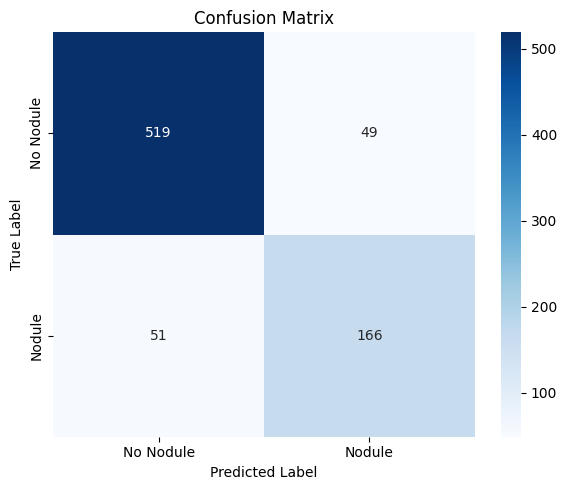

In [133]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(test_labels, test_preds)
cm_labels = ['No Nodule', 'Nodule']

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [134]:
# %% Load Best Model and Evaluate on Test Set
print("\nLoading best model for testing...")
#best_model_path = 'best_resvit_multiscale.pth'
##model = ResNetWithMultiScaleAttention(num_classes=2, pretrained=False, num_heads=2, dropout=0.1)
#model = model.to(device)
#checkpoint = torch.load(best_model_path)
#model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc, test_preds, test_labels, test_probs, test_prec, test_rec, test_f1, test_auc = validate(model, test_loader, criterion_cls, criterion_bbox, device)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_rec:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
print(f"Test ROC AUC: {test_auc:.4f}")

print(f"\n" + "="*70)
print("TEST SET RESULTS")
print("="*70)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['No Nodule', 'Nodule']))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix:")
print(cm)


Loading best model for testing...


Validation: 100%|██████████| 50/50 [00:12<00:00,  4.02it/s]


Test Loss: 0.3920
Test Accuracy: 87.26%
Test Precision: 0.7721
Test Recall: 0.7650
Test F1-score: 0.7685
Test ROC AUC: 0.9316

TEST SET RESULTS
Test Loss: 0.3920
Test Accuracy: 87.26%

Classification Report:
              precision    recall  f1-score   support

   No Nodule       0.91      0.91      0.91       568
      Nodule       0.77      0.76      0.77       217

    accuracy                           0.87       785
   macro avg       0.84      0.84      0.84       785
weighted avg       0.87      0.87      0.87       785


Confusion Matrix:
[[519  49]
 [ 51 166]]


In [136]:
# %% Evaluate Bounding Box Performance on Test Set
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score

def calculate_iou(pred_bbox, gt_bbox):
    """
    Calculate IoU between predicted and ground truth bboxes
    Both bboxes are in format [x, y, w, h] (normalized [0, 1])
    """
    # Convert to [x1, y1, x2, y2] format
    pred_x1 = pred_bbox[0]
    pred_y1 = pred_bbox[1]
    pred_x2 = pred_bbox[0] + pred_bbox[2]
    pred_y2 = pred_bbox[1] + pred_bbox[3]
    
    gt_x1 = gt_bbox[0]
    gt_y1 = gt_bbox[1]
    gt_x2 = gt_bbox[0] + gt_bbox[2]
    gt_y2 = gt_bbox[1] + gt_bbox[3]
    
    # Calculate intersection
    inter_x1 = max(pred_x1, gt_x1)
    inter_y1 = max(pred_y1, gt_y1)
    inter_x2 = min(pred_x2, gt_x2)
    inter_y2 = min(pred_y2, gt_y2)
    
    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    
    # Calculate union
    pred_area = pred_bbox[2] * pred_bbox[3]
    gt_area = gt_bbox[2] * gt_bbox[3]
    union_area = pred_area + gt_area - inter_area
    
    # Calculate IoU
    iou = inter_area / union_area if union_area > 0 else 0
    return iou

def pointing_game_accuracy(pred_bbox, gt_bbox):
    """
    Check if the center of predicted bbox falls within ground truth bbox
    Returns 1 if hit, 0 if miss
    """
    # Center of predicted bbox
    pred_center_x = pred_bbox[0] + pred_bbox[2] / 2
    pred_center_y = pred_bbox[1] + pred_bbox[3] / 2
    
    # Check if center is inside ground truth bbox
    gt_x1 = gt_bbox[0]
    gt_y1 = gt_bbox[1]
    gt_x2 = gt_bbox[0] + gt_bbox[2]
    gt_y2 = gt_bbox[1] + gt_bbox[3]
    
    hit = (gt_x1 <= pred_center_x <= gt_x2) and (gt_y1 <= pred_center_y <= gt_y2)
    return 1 if hit else 0

print("\nLoading best model for bbox testing...")
#checkpoint = torch.load(best_model_path)
#model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Collect predictions
all_class_preds = []
all_class_labels = []
all_class_probs = []
all_bbox_preds = []
all_bbox_gts = []
all_ious = []
all_pointing_game = []

running_loss = 0.0
correct = 0
total = 0

print("\nEvaluating bounding boxes on test set...")
with torch.no_grad():
    for images, labels, bboxes in tqdm(test_loader, desc='Testing BBox'):
        images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)
        
        class_logits, bbox_pred = model(images)
        
        # Classification loss
        cls_loss = criterion_cls(class_logits, labels)
        bbox_loss = criterion_bbox(bbox_pred, bboxes)
        loss = cls_loss + BBOX_LOSS_WEIGHT * bbox_loss
        
        running_loss += loss.item()
        
        # Classification metrics
        probs = torch.softmax(class_logits, dim=1)
        _, predicted = class_logits.max(1)
        
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_class_preds.extend(predicted.cpu().numpy())
        all_class_labels.extend(labels.cpu().numpy())
        all_class_probs.extend(probs[:, 1].cpu().numpy())
        
        # Bbox metrics
        bbox_pred_np = bbox_pred.cpu().numpy()
        bbox_gt_np = bboxes.cpu().numpy()
        
        all_bbox_preds.extend(bbox_pred_np)
        all_bbox_gts.extend(bbox_gt_np)
        
        # Calculate IoU and Pointing Game for each sample
        for pred, gt in zip(bbox_pred_np, bbox_gt_np):
            iou = calculate_iou(pred, gt)
            pg = pointing_game_accuracy(pred, gt)
            all_ious.append(iou)
            all_pointing_game.append(pg)

# Calculate metrics
test_loss = running_loss / len(test_loader)
test_acc = 100. * correct / total

# Classification metrics
test_auc = roc_auc_score(all_class_labels, all_class_probs)
test_precision = precision_score(all_class_labels, all_class_preds, average='binary', zero_division=0)
test_recall = recall_score(all_class_labels, all_class_preds, average='binary', zero_division=0)
test_f1 = f1_score(all_class_labels, all_class_preds, average='binary', zero_division=0)

# Bbox metrics
mean_iou = np.mean(all_ious)
median_iou = np.median(all_ious)
iou_std = np.std(all_ious)
pointing_game_acc = np.mean(all_pointing_game) * 100

# IoU thresholds for detection metrics
iou_50 = np.mean([iou >= 0.5 for iou in all_ious]) * 100  # % of predictions with IoU >= 0.5
iou_75 = np.mean([iou >= 0.75 for iou in all_ious]) * 100  # % of predictions with IoU >= 0.75

# Calculate mAP (Mean Average Precision) at different IoU thresholds
iou_thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
aps = []
for thresh in iou_thresholds:
    ap = np.mean([iou >= thresh for iou in all_ious])
    aps.append(ap)
map_score = np.mean(aps) * 100

print("\n" + "="*70)
print("TEST SET RESULTS - BOUNDING BOX EVALUATION")
print("="*70)

print("\nCLASSIFICATION METRICS:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.2f}%")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")
print(f"  ROC AUC: {test_auc:.4f}")

print("\nBOUNDING BOX METRICS:")
print(f"  Mean IoU: {mean_iou:.4f}")
print(f"  Median IoU: {median_iou:.4f}")
print(f"  IoU Std Dev: {iou_std:.4f}")
print(f"  IoU@0.5 (Precision): {iou_50:.2f}%")
print(f"  IoU@0.75 (Precision): {iou_75:.2f}%")
print(f"  Pointing Game Accuracy: {pointing_game_acc:.2f}%")
print(f"  mAP@[0.5:0.95]: {map_score:.2f}%")

print("\nDETECTION PERFORMANCE:")
print(f"  True Positives (IoU≥0.5): {int(iou_50 * len(all_ious) / 100)}/{len(all_ious)}")
print(f"  False Positives (IoU<0.5): {int((100-iou_50) * len(all_ious) / 100)}/{len(all_ious)}")

print("\n" + "="*70)

print("\nClassification Report:")
print(classification_report(all_class_labels, all_class_preds, 
                          target_names=['No Nodule', 'Nodule']))

print("\nIoU Distribution:")
iou_bins = [0, 0.25, 0.5, 0.75, 1.0]
for i in range(len(iou_bins)-1):
    count = sum([iou_bins[i] <= iou < iou_bins[i+1] for iou in all_ious])
    percentage = (count / len(all_ious)) * 100
    print(f"  IoU [{iou_bins[i]:.2f} - {iou_bins[i+1]:.2f}): {count:4d} samples ({percentage:5.2f}%)")

print("\nmAP per IoU Threshold:")
for thresh, ap in zip(iou_thresholds, aps):
    print(f"  AP@{thresh:.2f}: {ap*100:.2f}%")


Loading best model for bbox testing...

Evaluating bounding boxes on test set...


Testing BBox: 100%|██████████| 50/50 [00:12<00:00,  4.02it/s]


TEST SET RESULTS - BOUNDING BOX EVALUATION

CLASSIFICATION METRICS:
  Test Loss: 4.2277
  Test Accuracy: 87.26%
  Precision: 0.7721
  Recall: 0.7650
  F1 Score: 0.7685
  ROC AUC: 0.9316

BOUNDING BOX METRICS:
  Mean IoU: 0.0012
  Median IoU: 0.0000
  IoU Std Dev: 0.0147
  IoU@0.5 (Precision): 0.00%
  IoU@0.75 (Precision): 0.00%
  Pointing Game Accuracy: 0.51%
  mAP@[0.5:0.95]: 0.00%

DETECTION PERFORMANCE:
  True Positives (IoU≥0.5): 0/785
  False Positives (IoU<0.5): 785/785


Classification Report:
              precision    recall  f1-score   support

   No Nodule       0.91      0.91      0.91       568
      Nodule       0.77      0.76      0.77       217

    accuracy                           0.87       785
   macro avg       0.84      0.84      0.84       785
weighted avg       0.87      0.87      0.87       785


IoU Distribution:
  IoU [0.00 - 0.25):  784 samples (99.87%)
  IoU [0.25 - 0.50):    1 samples ( 0.13%)
  IoU [0.50 - 0.75):    0 samples ( 0.00%)
  IoU [0.75 - 1.00


Visualizing bbox predictions on random validation samples...


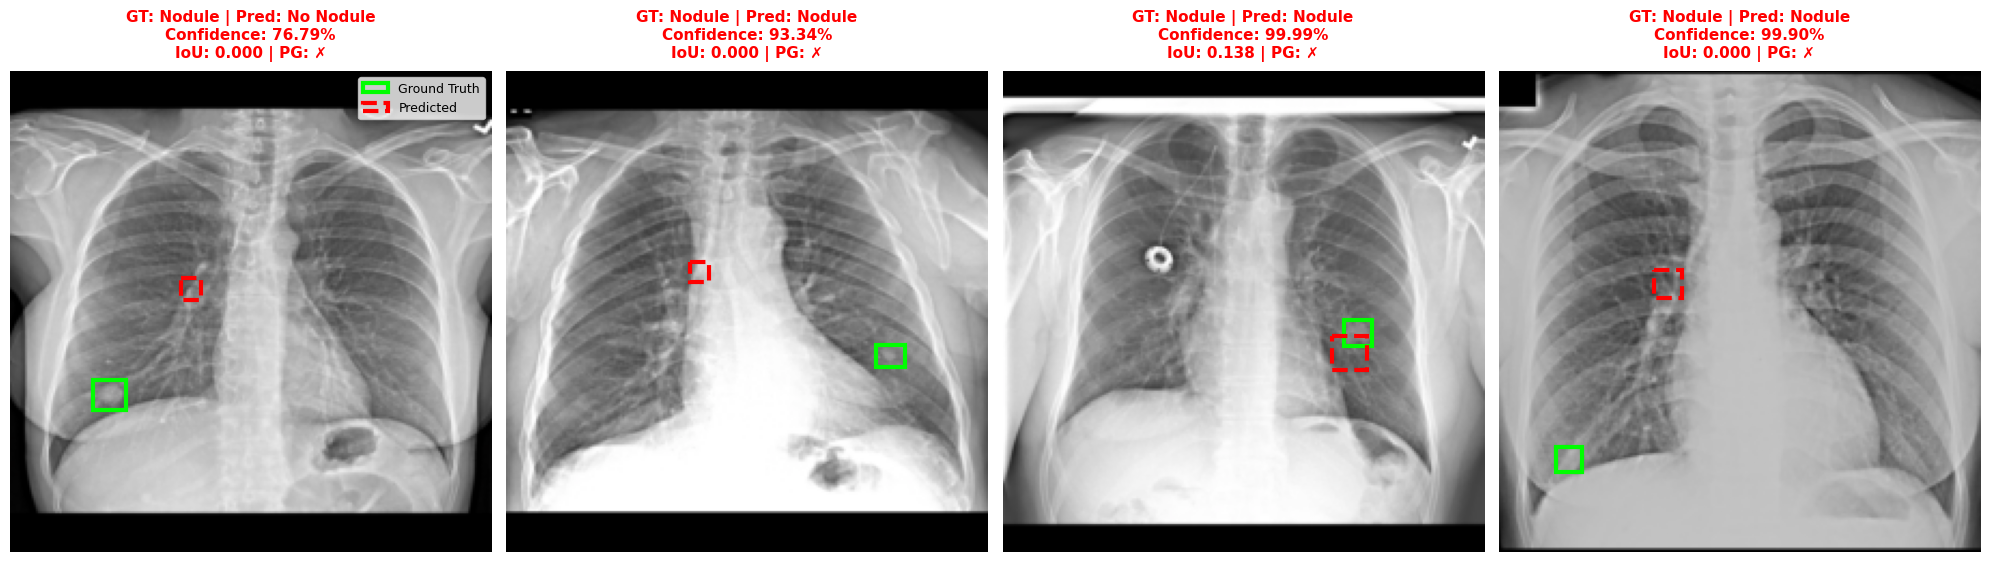


✓ Visualization saved as 'bbox_predictions_val.png'


In [137]:
# %% Visualize Bbox Predictions on Random Validation Images
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def denormalize_image(img_tensor):
    """Denormalize image from ImageNet normalization"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    img = torch.clamp(img, 0, 1)
    return img

def visualize_bbox_prediction(model, dataset, device, num_samples=4, save_name='bbox_predictions_visualization.png'):
    """Visualize random samples with ground truth and predicted bboxes"""
    model.eval()
    
    # Randomly select samples with nodules (label == 1) for better visualization
    nodule_indices = [i for i in range(len(dataset)) if dataset.df.iloc[i]['label'] == 1]
    if len(nodule_indices) < num_samples:
        # If not enough nodules, use all available indices
        indices = np.random.choice(len(dataset), num_samples, replace=False)
    else:
        indices = np.random.choice(nodule_indices, num_samples, replace=False)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(5*num_samples, 6))
    if num_samples == 1:
        axes = [axes]
    
    with torch.no_grad():
        for idx, ax in zip(indices, axes):
            image, label, bbox_gt = dataset[idx]
            
            # Get prediction
            image_batch = image.unsqueeze(0).to(device)
            class_logits, bbox_pred = model(image_batch)
            
            # Get classification result
            probs = torch.softmax(class_logits, dim=1)
            pred_class = class_logits.argmax(1).item()
            pred_prob = probs[0, pred_class].item()
            
            # Get bbox prediction
            bbox_pred = bbox_pred.squeeze(0).cpu().numpy()
            bbox_gt = bbox_gt.numpy()
            
            # Denormalize image for display
            img_display = denormalize_image(image).permute(1, 2, 0).numpy()
            
            # Display image
            ax.imshow(img_display)
            
            # Convert normalized bbox to pixel coordinates (224×224)
            def bbox_to_rect(bbox, color, label, linestyle='-'):
                x, y, w, h = bbox
                x_pixel = x * IMAGE_SIZE
                y_pixel = y * IMAGE_SIZE
                w_pixel = w * IMAGE_SIZE
                h_pixel = h * IMAGE_SIZE
                rect = patches.Rectangle((x_pixel, y_pixel), w_pixel, h_pixel,
                                        linewidth=3, edgecolor=color, facecolor='none',
                                        label=label, linestyle=linestyle)
                return rect
            
            # Draw ground truth bbox (green solid line)
            rect_gt = bbox_to_rect(bbox_gt, 'lime', 'Ground Truth', '-')
            ax.add_patch(rect_gt)
            
            # Draw predicted bbox (red dashed line)
            rect_pred = bbox_to_rect(bbox_pred, 'red', 'Predicted', '--')
            ax.add_patch(rect_pred)
            
            # Calculate IoU for this sample
            iou = calculate_iou(bbox_pred, bbox_gt)
            pg = pointing_game_accuracy(bbox_pred, bbox_gt)
            
            # Title with classification and bbox info
            class_name = 'Nodule' if label == 1 else 'No Nodule'
            pred_name = 'Nodule' if pred_class == 1 else 'No Nodule'
            
            # Color code based on performance
            title_color = 'green' if pred_class == label and iou >= 0.5 else 'red'
            
            title = f'GT: {class_name} | Pred: {pred_name}\n'
            title += f'Confidence: {pred_prob:.2%}\n'
            title += f'IoU: {iou:.3f} | PG: {"✓" if pg else "✗"}'
            
            ax.set_title(title, fontsize=11, fontweight='bold', color=title_color, pad=10)
            ax.axis('off')
            
            # Add legend only to first subplot
            if idx == indices[0]:
                ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
    
    plt.tight_layout()
    plt.show()
    print(f"\n✓ Visualization saved as '{save_name}'")

# Run visualization on VALIDATION SET
print("\nVisualizing bbox predictions on random validation samples...")
visualize_bbox_prediction(model, val_dataset, device, num_samples=4, 
                         save_name='bbox_predictions_val.png')


VISUALIZING BBOX PREDICTIONS ON TRAINING SET


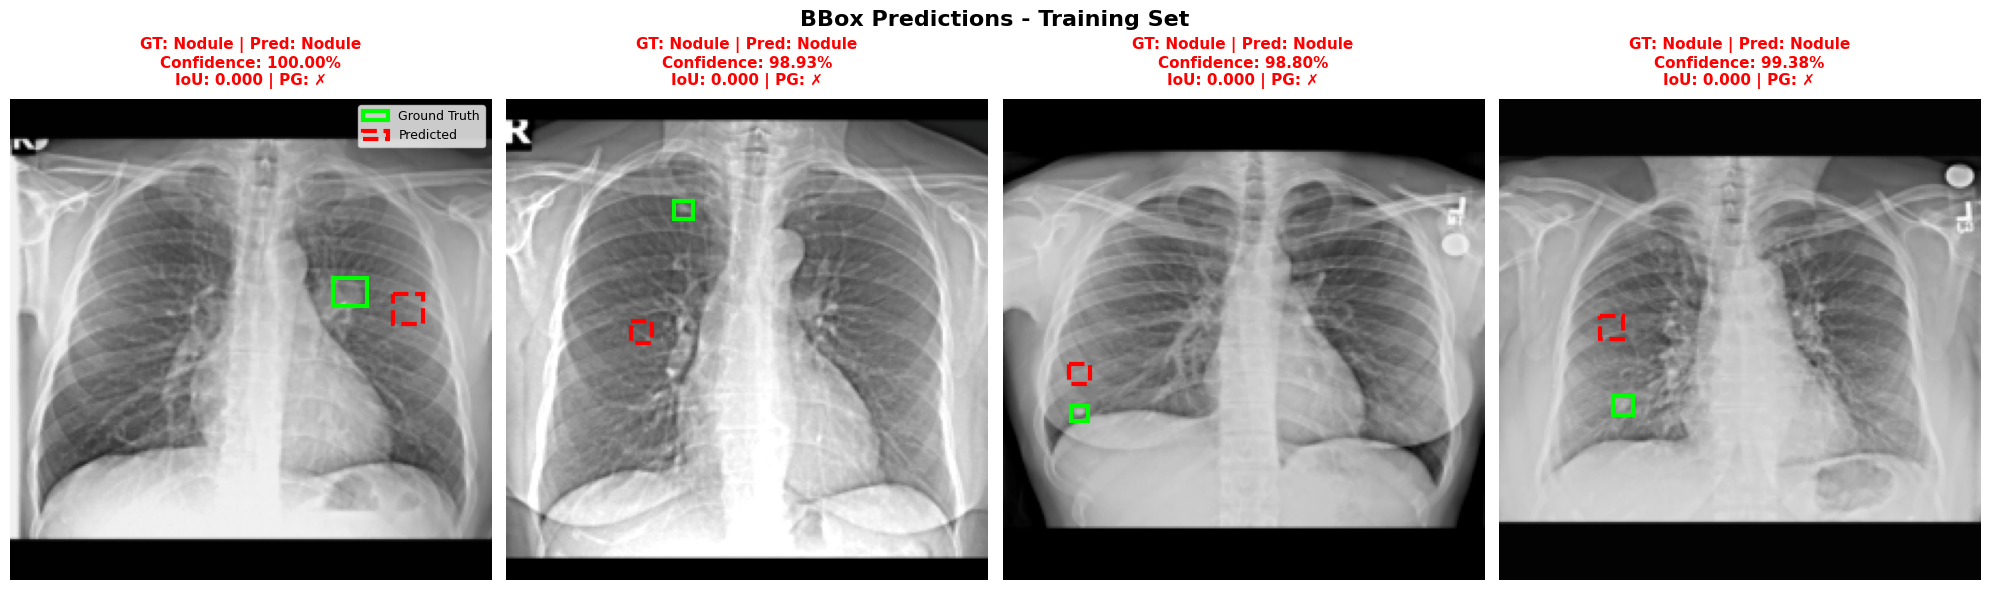


✓ Visualization saved as 'bbox_predictions_train.png'

VISUALIZING BBOX PREDICTIONS ON VALIDATION SET


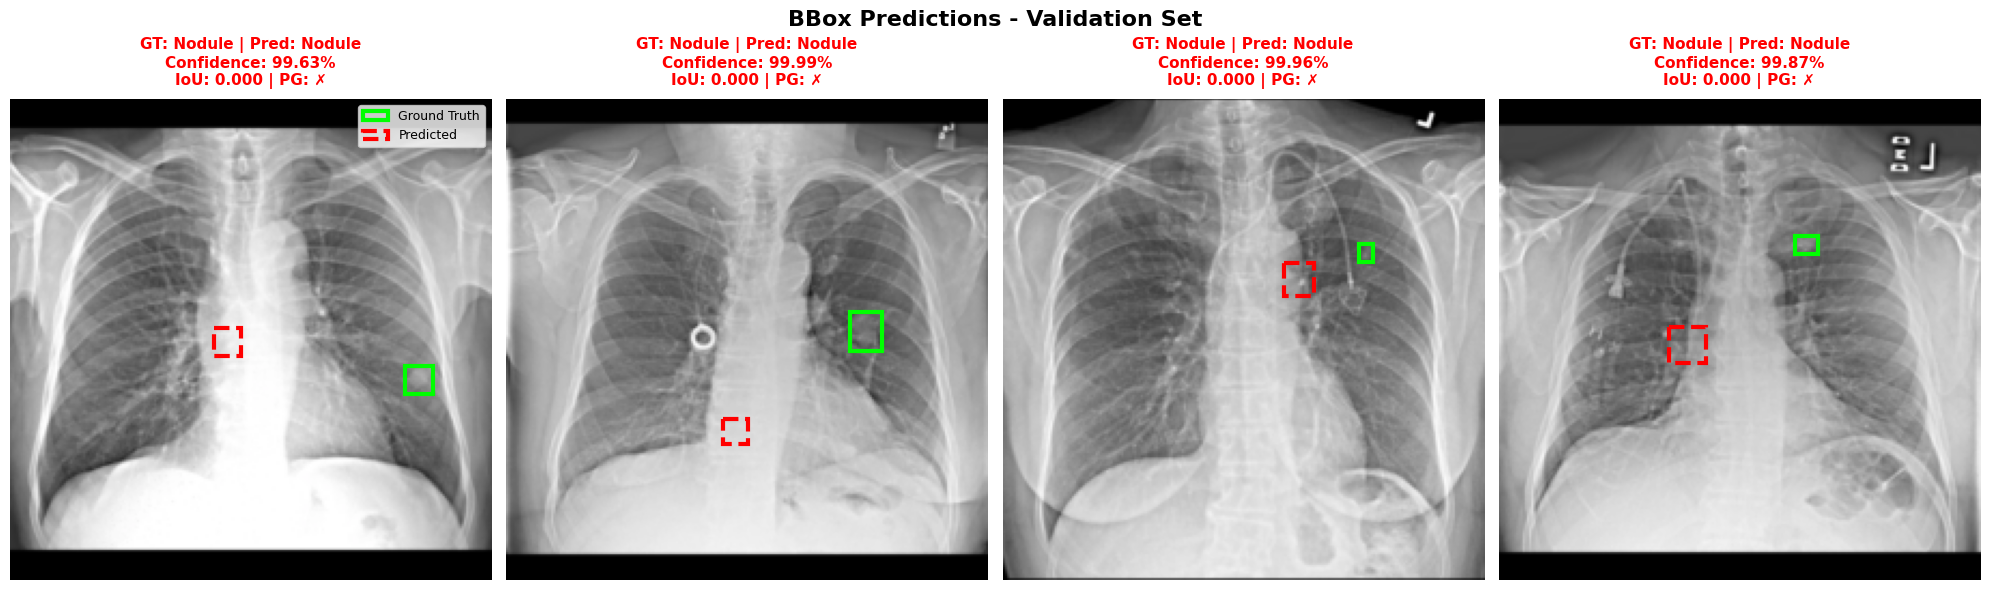


✓ Visualization saved as 'bbox_predictions_val.png'


In [152]:
# %% Visualize Bbox Predictions on Random Train and Validation Images
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def denormalize_image(img_tensor):
    """Denormalize image from ImageNet normalization"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    img = torch.clamp(img, 0, 1)
    return img

def visualize_bbox_prediction(model, dataset, device, num_samples=4, save_name='bbox_predictions_visualization.png', dataset_name='Dataset'):
    """Visualize random samples with ground truth and predicted bboxes"""
    model.eval()
    
    # Randomly select samples with nodules (label == 1) for better visualization
    nodule_indices = [i for i in range(len(dataset)) if dataset.df.iloc[i]['label'] == 1]
    if len(nodule_indices) < num_samples:
        # If not enough nodules, use all available indices
        indices = np.random.choice(len(dataset), num_samples, replace=False)
    else:
        indices = np.random.choice(nodule_indices, num_samples, replace=False)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(5*num_samples, 6))
    if num_samples == 1:
        axes = [axes]
    
    with torch.no_grad():
        for idx, ax in zip(indices, axes):
            image, label, bbox_gt = dataset[idx]
            
            # Get prediction
            image_batch = image.unsqueeze(0).to(device)
            class_logits, bbox_pred = model(image_batch)
            
            # Get classification result
            probs = torch.softmax(class_logits, dim=1)
            pred_class = class_logits.argmax(1).item()
            pred_prob = probs[0, pred_class].item()
            
            # Get bbox prediction
            bbox_pred = bbox_pred.squeeze(0).cpu().numpy()
            bbox_gt = bbox_gt.numpy()
            
            # Denormalize image for display
            img_display = denormalize_image(image).permute(1, 2, 0).numpy()
            
            # Display image
            ax.imshow(img_display)
            
            # Convert normalized bbox to pixel coordinates (224×224)
            def bbox_to_rect(bbox, color, label, linestyle='-'):
                x, y, w, h = bbox
                x_pixel = x * IMAGE_SIZE
                y_pixel = y * IMAGE_SIZE
                w_pixel = w * IMAGE_SIZE
                h_pixel = h * IMAGE_SIZE
                rect = patches.Rectangle((x_pixel, y_pixel), w_pixel, h_pixel,
                                        linewidth=3, edgecolor=color, facecolor='none',
                                        label=label, linestyle=linestyle)
                return rect
            
            # Draw ground truth bbox (green solid line)
            rect_gt = bbox_to_rect(bbox_gt, 'lime', 'Ground Truth', '-')
            ax.add_patch(rect_gt)
            
            # Draw predicted bbox (red dashed line)
            rect_pred = bbox_to_rect(bbox_pred, 'red', 'Predicted', '--')
            ax.add_patch(rect_pred)
            
            # Calculate IoU for this sample
            iou = calculate_iou(bbox_pred, bbox_gt)
            pg = pointing_game_accuracy(bbox_pred, bbox_gt)
            
            # Title with classification and bbox info
            class_name = 'Nodule' if label == 1 else 'No Nodule'
            pred_name = 'Nodule' if pred_class == 1 else 'No Nodule'
            
            # Color code based on performance
            title_color = 'green' if pred_class == label and iou >= 0.5 else 'red'
            
            title = f'GT: {class_name} | Pred: {pred_name}\n'
            title += f'Confidence: {pred_prob:.2%}\n'
            title += f'IoU: {iou:.3f} | PG: {"✓" if pg else "✗"}'
            
            ax.set_title(title, fontsize=11, fontweight='bold', color=title_color, pad=10)
            ax.axis('off')
            
            # Add legend only to first subplot
            if idx == indices[0]:
                ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
    
    # Add dataset name to the main title
    fig.suptitle(f'BBox Predictions - {dataset_name}', fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()
    print(f"\n✓ Visualization saved as '{save_name}'")

# ===== Visualize on TRAINING SET =====
print("\n" + "="*70)
print("VISUALIZING BBOX PREDICTIONS ON TRAINING SET")
print("="*70)
visualize_bbox_prediction(model, train_dataset, device, num_samples=4, 
                         save_name='bbox_predictions_train.png',
                         dataset_name='Training Set')

# ===== Visualize on VALIDATION SET =====
print("\n" + "="*70)
print("VISUALIZING BBOX PREDICTIONS ON VALIDATION SET")
print("="*70)
visualize_bbox_prediction(model, val_dataset, device, num_samples=4, 
                         save_name='bbox_predictions_val.png',
                         dataset_name='Validation Set')